# HALCCON - Notebook base en PyTorch

Este notebook está pensado para:

1. cargar los CSV ya separados (`train.csv`, `val.csv`, `test.csv`) o tensores ya guardados,
2. reproducir el preproceso principal (`drop` → label encoding del target → CatBoost encoding → Min-Max),
3. convertir a tensores PyTorch,
4. entrenar y evaluar una versión estilo HALCCON en PyTorch,
5. auditar shapes, columnas, estadísticas y resultados.

La lógica sigue el flujo del pipeline actual, pero en formato notebook para inspección paso a paso.


In [56]:
# =========================
# 1) Imports y raíz del proyecto
# =========================
import sys
import json
import math
import shutil
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from category_encoders import CatBoostEncoder
from tqdm import tqdm

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())
print("models exists:", (PROJECT_ROOT / "src" / "models").exists())


PROJECT_ROOT: c:\Users\rodol\OneDrive - SEIENER\03_Maestria\000_TESIS_ciberseguridad\worspace_visual\HALCCON_MULTICLASE
src exists: True
models exists: True


In [57]:
# =========================
# 2) Configuración editable
# =========================
DATASET_NAME = "unsw_nb15"

SPLITS_DIR = PROJECT_ROOT / "02_data" / "split" / DATASET_NAME
RAW_DIR = PROJECT_ROOT / "02_data" / "raw" / "data_unsw-nb15"
PROCESSED_DIR = PROJECT_ROOT / "02_data" / "processed" / DATASET_NAME
ARTIFACT_DIR = PROCESSED_DIR / "catboost_label__clean_notebook"

TARGET_COL = "attack_cat"
DROP_COLS = ["id", "label"]   # attack_cat se separa aparte como target
CAT_COLS = ["proto", "service", "state"]

BATCH_SIZE = 256
NUM_EPOCHS = 30
LEARNING_RATE = 5e-4
SEED = 42

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

print("SPLITS_DIR exists:", SPLITS_DIR.exists())
print("RAW_DIR exists   :", RAW_DIR.exists())
print("PROCESSED_DIR exists:", PROCESSED_DIR.exists())
print("Artifact dir:", ARTIFACT_DIR)

SPLITS_DIR exists: True
RAW_DIR exists   : True
PROCESSED_DIR exists: True
Artifact dir: c:\Users\rodol\OneDrive - SEIENER\03_Maestria\000_TESIS_ciberseguridad\worspace_visual\HALCCON_MULTICLASE\02_data\processed\unsw_nb15\catboost_label__clean_notebook


In [58]:
# =========================
# 3) Cargar splits CSV (robusto)
# =========================
train_split_path = SPLITS_DIR / "train.csv"
val_split_path = SPLITS_DIR / "val.csv"
test_split_path = SPLITS_DIR / "test.csv"

raw_train_path = RAW_DIR / "UNSW_NB15_training-set.csv"
raw_test_path = RAW_DIR / "UNSW_NB15_testing-set.csv"

print("Expected split paths:")
print(" -", train_split_path)
print(" -", val_split_path)
print(" -", test_split_path)

print("\nExpected raw paths:")
print(" -", raw_train_path)
print(" -", raw_test_path)

use_saved_splits = (
    train_split_path.exists() and
    val_split_path.exists() and
    test_split_path.exists()
)

if use_saved_splits:
    print("\n[INFO] Loading pre-generated split CSVs...")
    train_df = pd.read_csv(train_split_path)
    val_df = pd.read_csv(val_split_path)
    test_df = pd.read_csv(test_split_path)
else:
    print("\n[INFO] Split CSVs not found. Loading official raw UNSW files and creating internal validation split...")

    if not raw_train_path.exists():
        raise FileNotFoundError(f"Raw training file not found: {raw_train_path}")
    if not raw_test_path.exists():
        raise FileNotFoundError(f"Raw testing file not found: {raw_test_path}")

    train_full_df = pd.read_csv(raw_train_path)
    test_df = pd.read_csv(raw_test_path)

    if TARGET_COL not in train_full_df.columns:
        raise ValueError(f"Target column '{TARGET_COL}' not found in raw training file.")
    if TARGET_COL not in test_df.columns:
        raise ValueError(f"Target column '{TARGET_COL}' not found in raw testing file.")

    train_df, val_df = train_test_split(
        train_full_df,
        test_size=0.15,
        random_state=SEED,
        stratify=train_full_df[TARGET_COL]
    )

    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

print("\nLoaded shapes:")
print("train:", train_df.shape)
print("val  :", val_df.shape)
print("test :", test_df.shape)

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    if TARGET_COL not in df.columns:
        raise ValueError(f"Target column '{TARGET_COL}' missing in {name}_df")

print("\nColumns match train/val:", list(train_df.columns) == list(val_df.columns))
print("Columns match train/test:", list(train_df.columns) == list(test_df.columns))

display(train_df.head(2))

Expected split paths:
 - c:\Users\rodol\OneDrive - SEIENER\03_Maestria\000_TESIS_ciberseguridad\worspace_visual\HALCCON_MULTICLASE\02_data\split\unsw_nb15\train.csv
 - c:\Users\rodol\OneDrive - SEIENER\03_Maestria\000_TESIS_ciberseguridad\worspace_visual\HALCCON_MULTICLASE\02_data\split\unsw_nb15\val.csv
 - c:\Users\rodol\OneDrive - SEIENER\03_Maestria\000_TESIS_ciberseguridad\worspace_visual\HALCCON_MULTICLASE\02_data\split\unsw_nb15\test.csv

Expected raw paths:
 - c:\Users\rodol\OneDrive - SEIENER\03_Maestria\000_TESIS_ciberseguridad\worspace_visual\HALCCON_MULTICLASE\02_data\raw\data_unsw-nb15\UNSW_NB15_training-set.csv
 - c:\Users\rodol\OneDrive - SEIENER\03_Maestria\000_TESIS_ciberseguridad\worspace_visual\HALCCON_MULTICLASE\02_data\raw\data_unsw-nb15\UNSW_NB15_testing-set.csv

[INFO] Loading pre-generated split CSVs...

Loaded shapes:
train: (149039, 45)
val  : (26302, 45)
test : (82332, 45)

Columns match train/val: True
Columns match train/test: True


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,167073,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,0,5.066666e+07,0.0,0,0,0.009000,0.0,0.000000,0.0,0,0,0,0,0.0,0.0,0.0,57,0,0,0,22,2,22,22,8,22,0,0,0,22,22,0,Generic,1
1,148544,59.810604,ospf,-,INT,130,0,35360,0,2.156808,254,0,4.693214e+03,0.0,0,0,463.647906,0.0,553.786375,0.0,0,0,0,0,0.0,0.0,0.0,272,0,0,0,2,2,2,2,2,2,0,0,0,2,2,0,Exploits,1


In [59]:

# =========================
# 4) Auditoría rápida de columnas
# =========================
print("¿Mismas columnas train/val?", list(train_df.columns) == list(val_df.columns))
print("¿Mismas columnas train/test?", list(train_df.columns) == list(test_df.columns))

print("\nColumnas:")
print(train_df.columns.tolist())

for col in [TARGET_COL, *DROP_COLS]:
    print(f"{col}: train={col in train_df.columns}, val={col in val_df.columns}, test={col in test_df.columns}")


¿Mismas columnas train/val? True
¿Mismas columnas train/test? True

Columnas:
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']
attack_cat: train=True, val=True, test=True
id: train=True, val=True, test=True
label: train=True, val=True, test=True


In [60]:
# =========================
# 4) Separar X / y
# =========================
X_train = train_df.drop(columns=DROP_COLS + [TARGET_COL]).copy()
X_val   = val_df.drop(columns=DROP_COLS + [TARGET_COL]).copy()
X_test  = test_df.drop(columns=DROP_COLS + [TARGET_COL]).copy()

y_train_raw = train_df[TARGET_COL].copy()
y_val_raw   = val_df[TARGET_COL].copy()
y_test_raw  = test_df[TARGET_COL].copy()

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("\nMismas columnas train/val:", list(X_train.columns) == list(X_val.columns))
print("Mismas columnas train/test:", list(X_train.columns) == list(X_test.columns))

print("\nFeatures:")
print(X_train.columns.tolist())

X_train: (149039, 42)
X_val  : (26302, 42)
X_test : (82332, 42)

Mismas columnas train/val: True
Mismas columnas train/test: True

Features:
['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']


In [61]:
# =========================
# 5) LabelEncoder del target
# =========================
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train_raw)
y_val   = label_encoder.transform(y_val_raw)
y_test  = label_encoder.transform(y_test_raw)

num_classes = len(label_encoder.classes_)
class_mapping = {cls: int(i) for i, cls in enumerate(label_encoder.classes_)}

print("num_classes:", num_classes)
print("classes:", label_encoder.classes_)
print("class_mapping:", class_mapping)

num_classes: 10
classes: ['Analysis' 'Backdoor' 'DoS' 'Exploits' 'Fuzzers' 'Generic' 'Normal'
 'Reconnaissance' 'Shellcode' 'Worms']
class_mapping: {'Analysis': 0, 'Backdoor': 1, 'DoS': 2, 'Exploits': 3, 'Fuzzers': 4, 'Generic': 5, 'Normal': 6, 'Reconnaissance': 7, 'Shellcode': 8, 'Worms': 9}


In [62]:
# =========================
# 6) CatBoost encoding
# =========================
X_train_cb = X_train.copy()
X_val_cb   = X_val.copy()
X_test_cb  = X_test.copy()

for col in CAT_COLS:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_val_cb[col]   = X_val_cb[col].astype(str)
    X_test_cb[col]  = X_test_cb[col].astype(str)

cb_encoder = CatBoostEncoder(
    cols=CAT_COLS,
    handle_unknown="value",
    handle_missing="value"
)

X_train_cb[CAT_COLS] = cb_encoder.fit_transform(X_train_cb[CAT_COLS], y_train)
X_val_cb[CAT_COLS]   = cb_encoder.transform(X_val_cb[CAT_COLS])
X_test_cb[CAT_COLS]  = cb_encoder.transform(X_test_cb[CAT_COLS])

print("X_train_cb:", X_train_cb.shape)
print("X_val_cb  :", X_val_cb.shape)
print("X_test_cb :", X_test_cb.shape)

print("\nObject columns in X_train_cb:", X_train_cb.select_dtypes(include=["object"]).columns.tolist())
print("Object columns in X_val_cb  :", X_val_cb.select_dtypes(include=["object"]).columns.tolist())
print("Object columns in X_test_cb :", X_test_cb.select_dtypes(include=["object"]).columns.tolist())

X_train_cb: (149039, 42)
X_val_cb  : (26302, 42)
X_test_cb : (82332, 42)

Object columns in X_train_cb: []
Object columns in X_val_cb  : []
Object columns in X_test_cb : []


In [63]:
# =========================
# 7) Estadísticas antes de normalizar
# =========================
def stats_table(df):
    return pd.DataFrame({
        "min": df.min(),
        "p25": df.quantile(0.25),
        "median": df.median(),
        "mean": df.mean(),
        "p75": df.quantile(0.75),
        "max": df.max(),
        "std": df.std(),
        "skew": df.skew(),
        "zero_pct": (df == 0).mean() * 100
    })

train_stats_cb = stats_table(X_train_cb)
test_stats_cb = stats_table(X_test_cb)

display(train_stats_cb.head())
display(test_stats_cb.head())

,min,p25,median,mean,p75,max,std,skew,zero_pct
dur,0.000000,0.000008,0.001585,1.354164,0.668442,59.999989,6.454654,7.517407,1.509001
proto,1.556707,4.866663,4.873188,4.681275,5.245137,5.999451,0.873277,-1.587003,0.000000
service,1.982638,4.582556,4.591229,4.670471,5.136339,6.018614,0.382619,-0.363500,0.000000
state,3.934024,4.334532,4.841628,4.671952,4.846005,5.926118,0.396928,1.292850,0.000000
spkts,1.000000,2.000000,2.000000,20.115728,12.000000,9492.000000,133.544998,40.994699,0.000000


,min,p25,median,mean,p75,max,std,skew,zero_pct
dur,0.000000,0.000008,0.014138,1.006756,0.719360,59.999989,4.710444,9.523750,1.153865
proto,2.598524,4.868741,4.868741,4.791389,5.246532,5.999451,0.735215,-2.154717,0.000000
service,2.033506,4.591734,4.591734,4.664992,5.137656,5.971516,0.357920,-0.470708,0.000000
state,4.334672,4.334672,4.845000,4.702180,4.845000,5.750639,0.399995,1.224151,0.000000
spkts,1.000000,2.000000,6.000000,18.666472,12.000000,10646.000000,133.916353,47.747777,0.000000


In [64]:
# =========================
# 8) Min-Max scaling igual al pipeline clean
# =========================
train_min = X_train_cb.min()
train_max = X_train_cb.max()
denom = (train_max - train_min).replace(0, 1.0)

X_train_scaled = (X_train_cb - train_min) / denom
X_val_scaled   = (X_val_cb   - train_min) / denom
X_test_scaled  = (X_test_cb  - train_min) / denom

print("Scaled shapes:")
print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled  :", X_val_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

print("\nGlobal stats:")
print("train min/max:", np.nanmin(X_train_scaled.values), np.nanmax(X_train_scaled.values))
print("val   min/max:", np.nanmin(X_val_scaled.values), np.nanmax(X_val_scaled.values))
print("test  min/max:", np.nanmin(X_test_scaled.values), np.nanmax(X_test_scaled.values))
print("train has_nan:", np.isnan(X_train_scaled.values).any(), "has_inf:", np.isinf(X_train_scaled.values).any())
print("val   has_nan:", np.isnan(X_val_scaled.values).any(), "has_inf:", np.isinf(X_val_scaled.values).any())
print("test  has_nan:", np.isnan(X_test_scaled.values).any(), "has_inf:", np.isinf(X_test_scaled.values).any())

Scaled shapes:
X_train_scaled: (149039, 42)
X_val_scaled  : (26302, 42)
X_test_scaled : (82332, 42)

Global stats:
train min/max: 0.0 1.0
val   min/max: 0.0 1.2312793369089163
test  min/max: -0.0027100271002710027 1.9257076805331637
train has_nan: False has_inf: False
val   has_nan: False has_inf: False
test  has_nan: False has_inf: False


In [65]:

# =========================
# 10) Features fuera de rango en val/test
# =========================
feature_range_check = pd.DataFrame({
    "train_min_scaled": X_train_scaled.min(),
    "train_max_scaled": X_train_scaled.max(),
    "val_min_scaled": X_val_scaled.min(),
    "val_max_scaled": X_val_scaled.max(),
    "test_min_scaled": X_test_scaled.min(),
    "test_max_scaled": X_test_scaled.max(),
})

print("Features con test_min < 0")
display(feature_range_check[feature_range_check["test_min_scaled"] < 0])

print("Features con test_max > 1")
display(feature_range_check[feature_range_check["test_max_scaled"] > 1].sort_values("test_max_scaled", ascending=False))


Features con test_min < 0


,train_min_scaled,train_max_scaled,val_min_scaled,val_max_scaled,test_min_scaled,test_max_scaled
sbytes,0.0,1.0,0.000001,1.029445,-3.176023e-07,1.139855
smean,0.0,1.0,0.000000,0.995257,-2.710027e-03,1.000000


Features con test_max > 1


,train_min_scaled,train_max_scaled,val_min_scaled,val_max_scaled,test_min_scaled,test_max_scaled
ackdat,0.0,1.0,0.000000,0.936338,0.000000e+00,1.925708
synack,0.0,1.0,0.000000,1.231279,0.000000e+00,1.891625
djit,0.0,1.0,0.000000,0.992748,0.000000e+00,1.600615
tcprtt,0.0,1.0,0.000000,0.891915,0.000000e+00,1.517121
ct_src_ltm,0.0,1.0,0.000000,1.180000,0.000000e+00,1.180000
ct_src_dport_ltm,0.0,1.0,0.000000,1.000000,0.000000e+00,1.160000
ct_dst_ltm,0.0,1.0,0.000000,1.000000,0.000000e+00,1.160000
sbytes,0.0,1.0,0.000001,1.029445,-3.176023e-07,1.139855
spkts,0.0,1.0,0.000000,1.013065,0.000000e+00,1.121589
sloss,0.0,1.0,0.000000,1.012223,0.000000e+00,1.120969


In [66]:
# =========================
# 9) Tensores y DataLoaders
# =========================
X_train_tensor = torch.tensor(X_train_scaled.values, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val_scaled.values, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_scaled.values, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor   = torch.tensor(y_val, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

print("Before channel:")
print("X_train_tensor:", X_train_tensor.shape)
print("X_val_tensor  :", X_val_tensor.shape)
print("X_test_tensor :", X_test_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)
print("y_val_tensor  :", y_val_tensor.shape)
print("y_test_tensor :", y_test_tensor.shape)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_loader))
print("train batch:", xb.shape, yb.shape)

xb, yb = next(iter(val_loader))
print("val batch:", xb.shape, yb.shape)

xb, yb = next(iter(test_loader))
print("test batch:", xb.shape, yb.shape)

Before channel:
X_train_tensor: torch.Size([149039, 42])
X_val_tensor  : torch.Size([26302, 42])
X_test_tensor : torch.Size([82332, 42])
y_train_tensor: torch.Size([149039])
y_val_tensor  : torch.Size([26302])
y_test_tensor : torch.Size([82332])
train batch: torch.Size([256, 42]) torch.Size([256])
val batch: torch.Size([256, 42]) torch.Size([256])
test batch: torch.Size([256, 42]) torch.Size([256])


## Modelo PyTorch estilo HALCCON

La arquitectura de abajo es una versión PyTorch compacta para inspección en notebook:

- convoluciones 1D
- max pooling
- batch norm
- atención simple por bloque
- capa fully connected final

Si quieres, esta parte luego se puede sustituir por la clase exacta del repositorio.


In [67]:
# =========================
# 11) EQLv2 corregida
# =========================
class EQLv2(nn.Module):
    def __init__(
        self,
        num_classes=13,
        gamma=12,
        mu=0.3,
        alpha=2.0,
        loss_weight=1.0,
        vis_grad=False,
        reset_class_counts_each_epoch=False
    ):
        super().__init__()
        self.gamma = gamma
        self.mu = mu
        self.alpha = alpha
        self.loss_weight = loss_weight
        self.num_classes = num_classes
        self.vis_grad = vis_grad
        self.reset_class_counts_each_epoch = reset_class_counts_each_epoch

        self.register_buffer("_pos_grad", torch.zeros(self.num_classes))
        self.register_buffer("_neg_grad", torch.zeros(self.num_classes))
        self.register_buffer("pos_neg", torch.zeros(self.num_classes))
        self.register_buffer("class_counts", torch.zeros(self.num_classes))

    def forward(self, y_pred, y_true):
        device = y_pred.device

        target = y_true.to(device)
        pred_class_logits = y_pred
        n_i, n_c = pred_class_logits.shape

        if n_c != self.num_classes:
            raise ValueError(
                f"num_classes mismatch: logits have {n_c} classes but EQLv2 was initialized with {self.num_classes}"
            )

        pos_w, neg_w = self.get_weight(pred_class_logits, target)
        weight = (pos_w + neg_w).view(-1).detach().to(device)

        cls_loss = F.cross_entropy(
            pred_class_logits,
            target,
            weight=weight,
            reduction="none"
        )
        cls_loss = torch.sum(cls_loss) / n_i

        self.collect_grad(pred_class_logits, target, pos_w, neg_w)
        return self.loss_weight * cls_loss

    def get_weight(self, cls_score, target):
        device = cls_score.device

        with torch.no_grad():
            counts = torch.bincount(target, minlength=self.num_classes).float().to(device)
            self.class_counts += counts

        class_weights = self.class_counts.sum() / (self.class_counts + 1e-10)
        class_weights = class_weights / (class_weights.max() + 1e-10)

        neg_w = self.map_func(self.pos_neg)
        pos_w = 1 + self.alpha * (1 - neg_w) * class_weights

        neg_w = neg_w.view(-1).to(device)
        pos_w = pos_w.view(-1).to(device)

        return pos_w, neg_w

    def map_func(self, x):
        return 1 / (1 + torch.exp(-self.gamma * (x - self.mu)))

    def collect_grad(self, cls_score, target, pos_w, neg_w):
        device = cls_score.device

        target_one_hot = F.one_hot(target, num_classes=self.num_classes).float().to(device)
        prob = torch.sigmoid(cls_score)
        grad = target_one_hot * (prob - 1) + (1 - target_one_hot) * prob
        grad = torch.abs(grad)

        grad_norm = torch.sum(grad, dim=0)
        grad_norm = grad_norm / (grad_norm.max() + 1e-10)

        pos_grad = torch.sum(grad * target_one_hot * pos_w.view(1, -1), dim=0) / (grad_norm + 1e-10)
        neg_grad = torch.sum(grad * (1 - target_one_hot) * neg_w.view(1, -1), dim=0) / (grad_norm + 1e-10)

        self._pos_grad += pos_grad.detach()
        self._neg_grad += neg_grad.detach()
        self.pos_neg = self._pos_grad / (self._neg_grad + 1e-10)

    def on_epoch_start(self):
        self._pos_grad.zero_()
        self._neg_grad.zero_()
        if self.reset_class_counts_each_epoch:
            self.class_counts.zero_()
            self.pos_neg.zero_()

    def on_epoch_end(self):
        print(f"Gradientes positivos acumulados por clase al final de la época: {self._pos_grad}")
        print(f"Gradientes negativos acumulados por clase al final de la época: {self._neg_grad}")
        print(f"Frecuencia de ejemplos por clase: {self.class_counts}")

In [68]:
# =========================
# 10) Atención y modelo
# =========================
class HierarchicalAttention1D(nn.Module):
    def __init__(self, in_features: int):
        super().__init__()
        self.attention = nn.Linear(in_features, in_features)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size, channels, length = x.size()
        x_flat = torch.flatten(x, start_dim=1)
        attn_weights = torch.tanh(self.attention(x_flat))
        attn_weights = attn_weights.reshape(batch_size, channels, length)
        return x * attn_weights


class HALCCONMulticlass(nn.Module):
    def __init__(self, input_dim: int, num_classes: int):
        super().__init__()

        self.input_dim = input_dim
        self.num_classes = num_classes

        self.conv1 = nn.Conv1d(in_channels=1, out_channels=64, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool1d(kernel_size=4)
        self.bn1 = nn.BatchNorm1d(64)

        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5, padding=2)
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        self.bn2 = nn.BatchNorm1d(128)

        self.conv3 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=5, padding=2)
        self.pool3 = nn.MaxPool1d(kernel_size=2)
        self.bn3 = nn.BatchNorm1d(256)

        length1 = self._pooled_length(input_dim, 4)
        length2 = self._pooled_length(length1, 2)
        length3 = self._pooled_length(length2, 2)

        if min(length1, length2, length3) < 1:
            raise ValueError(
                f"input_dim={input_dim} is too small for HALCCON pooling path "
                f"(lengths: {length1}, {length2}, {length3})"
            )

        self.length1 = length1
        self.length2 = length2
        self.length3 = length3

        self.attention1 = HierarchicalAttention1D(64 * length1)
        self.attention2 = HierarchicalAttention1D(128 * length2)
        self.attention3 = HierarchicalAttention1D(256 * length3)

        self.fc = nn.Linear(256 * length3, num_classes)
        self.relu = nn.ReLU()

    @staticmethod
    def _pooled_length(length: int, kernel_size: int, stride: int = None, padding: int = 0, dilation: int = 1) -> int:
        if stride is None:
            stride = kernel_size
        return math.floor((length + 2 * padding - dilation * (kernel_size - 1) - 1) / stride + 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() == 2:
            x = x.unsqueeze(1)
        elif x.dim() != 3:
            raise ValueError(f"Expected input shape (B, F) or (B, 1, F), got {tuple(x.shape)}")

        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool1(x)
        x = self.bn1(x)
        x = self.attention1(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool2(x)
        x = self.bn2(x)
        x = self.attention2(x)

        x = self.conv3(x)
        x = self.relu(x)
        x = self.pool3(x)
        x = self.bn3(x)
        x = self.attention3(x)

        x = torch.flatten(x, start_dim=1)
        x = self.fc(x)
        return x


# prueba rápida
input_dim = X_train_scaled.shape[1]
model_tmp = HALCCONMulticlass(input_dim=input_dim, num_classes=num_classes)

x = torch.randn(8, input_dim)
y = model_tmp(x)
print("Output from (B, F):", y.shape)

x2 = torch.randn(8, 1, input_dim)
y2 = model_tmp(x2)
print("Output from (B, 1, F):", y2.shape)

Output from (B, F): torch.Size([8, 10])
Output from (B, 1, F): torch.Size([8, 10])


device: cuda
input_dim: 42
num_classes: 10
batch inputs shape: torch.Size([256, 42])
batch targets shape: torch.Size([256])


Epoch [1/30]: 100%|██████████| 583/583 [00:06<00:00, 85.32batch/s, train_loss_batch=0.6485]


Epoch [1/30] | Train Loss: 0.7255 | Train Acc: 0.7645 | Val Loss: 0.6552 | Val Acc: 0.7796 | Val Precision Macro: 0.5219 | Val Recall Macro: 0.4389 | Val F1 Macro: 0.4271
Gradientes positivos acumulados por clase al final de la época: tensor([1472.9977, 1721.1471, 1681.0355, 2237.2217, 1498.3563, 1367.8287,
        1670.5886, 1727.9189, 1157.9385,  807.7932], device='cuda:0')
Gradientes negativos acumulados por clase al final de la época: tensor([10434.0029, 11617.8809, 11805.7578, 14002.9297, 11645.6084, 10299.7432,
        12198.9463, 12429.6514,  9974.3740,  7742.8672], device='cuda:0')
Frecuencia de ejemplos por clase: tensor([ 2000.,  1746., 12264., 33393., 18184., 40000., 56000., 10491.,  1133.,
          130.], device='cuda:0')


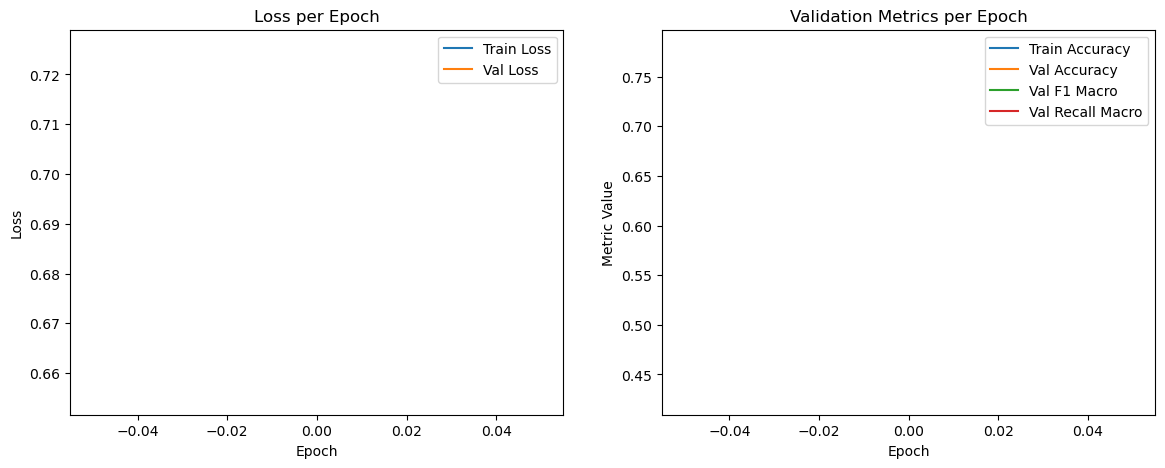

Epoch [2/30]: 100%|██████████| 583/583 [00:06<00:00, 83.83batch/s, train_loss_batch=0.8098]


Epoch [2/30] | Train Loss: 0.6259 | Train Acc: 0.7884 | Val Loss: 0.6190 | Val Acc: 0.7928 | Val Precision Macro: 0.7087 | Val Recall Macro: 0.4598 | Val F1 Macro: 0.4724
Gradientes positivos acumulados por clase al final de la época: tensor([1484.6869, 1667.5952, 1383.2207, 1792.5509, 1164.5963, 1276.2848,
        1234.7992, 1701.4064,  994.3748,  550.1909], device='cuda:0')
Gradientes negativos acumulados por clase al final de la época: tensor([10489.1172, 11455.3252, 10173.5938, 12156.9580,  9362.5703,  9645.3730,
         9742.9141, 11355.1807,  8892.6943,  6539.0737], device='cuda:0')
Frecuencia de ejemplos por clase: tensor([  4000.,   3492.,  24528.,  66786.,  36368.,  80000., 112000.,  20982.,
          2266.,    260.], device='cuda:0')


Epoch [3/30]: 100%|██████████| 583/583 [00:06<00:00, 84.79batch/s, train_loss_batch=0.7736]


Epoch [3/30] | Train Loss: 0.6026 | Train Acc: 0.7943 | Val Loss: 0.6685 | Val Acc: 0.7704 | Val Precision Macro: 0.6246 | Val Recall Macro: 0.4349 | Val F1 Macro: 0.4454
Gradientes positivos acumulados por clase al final de la época: tensor([1494.2056, 1722.9525, 1375.4979, 1764.3756, 1143.0920, 1220.6334,
        1200.4590, 1769.2452,  916.6396,  564.1891], device='cuda:0')
Gradientes negativos acumulados por clase al final de la época: tensor([10627.5859, 11526.7900, 10198.3311, 11710.7041,  9093.3027,  9348.9707,
         9340.8916, 11280.8047,  8126.2905,  6149.2407], device='cuda:0')
Frecuencia de ejemplos por clase: tensor([  6000.,   5238.,  36792., 100179.,  54552., 120000., 168000.,  31473.,
          3399.,    390.], device='cuda:0')


Epoch [4/30]: 100%|██████████| 583/583 [00:06<00:00, 87.25batch/s, train_loss_batch=0.4514]


...

Epoch [25/30]: 100%|██████████| 583/583 [00:07<00:00, 82.54batch/s, train_loss_batch=0.4308]


Epoch [25/30] | Train Loss: 0.4722 | Train Acc: 0.8335 | Val Loss: 0.5478 | Val Acc: 0.8163 | Val Precision Macro: 0.6497 | Val Recall Macro: 0.5399 | Val F1 Macro: 0.5382
Gradientes positivos acumulados por clase al final de la época: tensor([1335.1133, 1858.2065, 1275.7745, 1660.6688,  904.1617, 1098.7853,
         560.1196, 1427.6517,  435.4410,  365.5453], device='cuda:0')
Gradientes negativos acumulados por clase al final de la época: tensor([ 8941.3594, 11100.7568,  8673.0361, 10159.4199,  7144.5791,  7683.4365,
         5332.1289,  9371.2939,  4788.4487,  4060.0442], device='cuda:0')
Frecuencia de ejemplos por clase: tensor([  50000.,   43650.,  306600.,  834825.,  454600., 1000000., 1400000.,
         262275.,   28325.,    3250.], device='cuda:0')


Epoch [26/30]: 100%|██████████| 583/583 [00:06<00:00, 86.87batch/s, train_loss_batch=0.5849]


Epoch [26/30] | Train Loss: 0.4688 | Train Acc: 0.8347 | Val Loss: 0.5417 | Val Acc: 0.8151 | Val Precision Macro: 0.6190 | Val Recall Macro: 0.5613 | Val F1 Macro: 0.5567
Gradientes positivos acumulados por clase al final de la época: tensor([1406.4828, 1886.5936, 1303.8878, 1763.9009,  898.0746, 1077.9869,
         518.5903, 1498.2845,  408.9833,  419.2346], device='cuda:0')
Gradientes negativos acumulados por clase al final de la época: tensor([ 9321.4121, 11276.8887,  8894.8115, 10594.1533,  7179.1650,  7970.8706,
         5195.6558,  9651.1777,  4641.5640,  4464.1943], device='cuda:0')
Frecuencia de ejemplos por clase: tensor([  52000.,   45396.,  318864.,  868218.,  472784., 1040000., 1456000.,
         272766.,   29458.,    3380.], device='cuda:0')
Early stopping triggered
Loaded best model by val_f1_macro from: c:\Users\rodol\OneDrive - SEIENER\03_Maestria\000_TESIS_ciberseguridad\worspace_visual\HALCCON_MULTICLASE\02_data\processed\unsw_nb15\catboost_label__clean_notebook\best

C:\Users\rodol\AppData\Local\Temp\ipykernel_24296\4056629812.py:185: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_f1_path, map_locatio

In [69]:
# =========================
# 12) Entrenamiento integrado
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

input_dim = X_train_scaled.shape[1]
print("input_dim:", input_dim)
print("num_classes:", num_classes)

model = HALCCONMulticlass(input_dim=input_dim, num_classes=num_classes).to(device)
criterion = EQLv2(
    num_classes=num_classes,
    gamma=12,
    mu=0.3,
    alpha=2.0,
    loss_weight=1.0,
    vis_grad=False,
    reset_class_counts_each_epoch=False
).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_precision_macro": [],
    "val_recall_macro": [],
    "val_f1_macro": [],
    "val_precision_weighted": [],
    "val_recall_weighted": [],
    "val_f1_weighted": [],
}

patience = 8
best_val_loss = float("inf")
best_val_f1_macro = -1.0
best_epoch_by_val_loss = None
best_epoch_by_val_f1_macro = None
epochs_no_improve = 0

best_loss_path = ARTIFACT_DIR / "best_model_val_loss.pt"
best_f1_path = ARTIFACT_DIR / "best_model_val_f1_macro.pt"

xb, yb = next(iter(train_loader))
print("batch inputs shape:", xb.shape)
print("batch targets shape:", yb.shape)

plt.ion()
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for epoch in range(NUM_EPOCHS):
    criterion.on_epoch_start()
    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    with tqdm(train_loader, unit="batch") as tepoch:
        tepoch.set_description(f"Epoch [{epoch+1}/{NUM_EPOCHS}]")

        for inputs, targets in tepoch:
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs, dim=1)
            correct_predictions += (predicted == targets).sum().item()
            total_predictions += targets.size(0)

            tepoch.set_postfix({"train_loss_batch": f"{loss.item():.4f}"})

    epoch_loss = running_loss / total_predictions
    epoch_accuracy = correct_predictions / total_predictions

    history["train_loss"].append(epoch_loss)
    history["train_accuracy"].append(epoch_accuracy)

    model.eval()
    val_running_loss = 0.0
    val_correct_predictions = 0
    val_total_predictions = 0

    all_targets = []
    all_predictions = []

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            val_running_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs, dim=1)
            val_correct_predictions += (predicted == targets).sum().item()
            val_total_predictions += targets.size(0)

            all_targets.extend(targets.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    val_epoch_loss = val_running_loss / val_total_predictions
    val_epoch_accuracy = val_correct_predictions / val_total_predictions

    val_precision_macro = precision_score(all_targets, all_predictions, average="macro", zero_division=0)
    val_recall_macro = recall_score(all_targets, all_predictions, average="macro", zero_division=0)
    val_f1_macro = f1_score(all_targets, all_predictions, average="macro", zero_division=0)

    val_precision_weighted = precision_score(all_targets, all_predictions, average="weighted", zero_division=0)
    val_recall_weighted = recall_score(all_targets, all_predictions, average="weighted", zero_division=0)
    val_f1_weighted = f1_score(all_targets, all_predictions, average="weighted", zero_division=0)

    history["val_loss"].append(val_epoch_loss)
    history["val_accuracy"].append(val_epoch_accuracy)
    history["val_precision_macro"].append(val_precision_macro)
    history["val_recall_macro"].append(val_recall_macro)
    history["val_f1_macro"].append(val_f1_macro)
    history["val_precision_weighted"].append(val_precision_weighted)
    history["val_recall_weighted"].append(val_recall_weighted)
    history["val_f1_weighted"].append(val_f1_weighted)

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
        f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_accuracy:.4f} | "
        f"Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_accuracy:.4f} | "
        f"Val Precision Macro: {val_precision_macro:.4f} | "
        f"Val Recall Macro: {val_recall_macro:.4f} | "
        f"Val F1 Macro: {val_f1_macro:.4f}"
    )

    criterion.on_epoch_end()

    improved_loss = val_epoch_loss < best_val_loss
    improved_f1 = val_f1_macro > best_val_f1_macro

    if improved_loss:
        best_val_loss = val_epoch_loss
        best_epoch_by_val_loss = epoch + 1
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_loss_path)
    else:
        epochs_no_improve += 1

    if improved_f1:
        best_val_f1_macro = val_f1_macro
        best_epoch_by_val_f1_macro = epoch + 1
        torch.save(model.state_dict(), best_f1_path)

    if epochs_no_improve >= patience:
        print("Early stopping triggered")
        break

    ax[0].clear()
    ax[0].plot(history["train_loss"], label="Train Loss")
    ax[0].plot(history["val_loss"], label="Val Loss")
    ax[0].set_title("Loss per Epoch")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].legend()

    ax[1].clear()
    ax[1].plot(history["train_accuracy"], label="Train Accuracy")
    ax[1].plot(history["val_accuracy"], label="Val Accuracy")
    ax[1].plot(history["val_f1_macro"], label="Val F1 Macro")
    ax[1].plot(history["val_recall_macro"], label="Val Recall Macro")
    ax[1].set_title("Validation Metrics per Epoch")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Metric Value")
    ax[1].legend()

    plt.pause(0.1)

plt.ioff()
plt.show()

model.load_state_dict(torch.load(best_f1_path, map_location=device))
print("Loaded best model by val_f1_macro from:", best_f1_path)
print("best_epoch_by_val_loss:", best_epoch_by_val_loss)
print("best_epoch_by_val_f1_macro:", best_epoch_by_val_f1_macro)

In [72]:
# =========================
# 13) Evaluación integrada en test
# =========================
best_model_path = ARTIFACT_DIR / "best_model_val_f1_macro.pt"
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()

print("Loaded model from:", best_model_path)

test_correct_predictions = 0
test_total_predictions = 0
test_loss = 0.0

y_pred = []
y_true = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        test_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs, dim=1)
        test_correct_predictions += (predicted == targets).sum().item()
        test_total_predictions += targets.size(0)

        y_pred.extend(predicted.cpu().numpy())
        y_true.extend(targets.cpu().numpy())

test_loss = test_loss / test_total_predictions
test_accuracy = accuracy_score(y_true, y_pred)

test_precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
test_recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
test_f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

test_precision_weighted = precision_score(y_true, y_pred, average="weighted", zero_division=0)
test_recall_weighted = recall_score(y_true, y_pred, average="weighted", zero_division=0)
test_f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

cm = confusion_matrix(y_true, y_pred)

tp = np.diag(cm)
fp = np.sum(cm, axis=0) - tp
fn = np.sum(cm, axis=1) - tp
tn = cm.sum() - (fp + fn + tp)

fpr_per_class = fp / (fp + tn + 1e-10)
fpr_macro = np.mean(fpr_per_class)

print(f"Test Loss: {test_loss:.6f}")
print(f"Test Accuracy: {test_accuracy:.6f}")
print(f"Test Precision Macro: {test_precision_macro:.6f}")
print(f"Test Recall Macro: {test_recall_macro:.6f}")
print(f"Test F1 Macro: {test_f1_macro:.6f}")
print(f"Test Precision Weighted: {test_precision_weighted:.6f}")
print(f"Test Recall Weighted: {test_recall_weighted:.6f}")
print(f"Test F1 Weighted: {test_f1_weighted:.6f}")
print(f"Test FPR Macro: {fpr_macro:.8f}")

target_names = list(label_encoder.classes_)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

C:\Users\rodol\AppData\Local\Temp\ipykernel_24296\2699813181.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_locati

Loaded model from: c:\Users\rodol\OneDrive - SEIENER\03_Maestria\000_TESIS_ciberseguridad\worspace_visual\HALCCON_MULTICLASE\02_data\processed\unsw_nb15\catboost_label__clean_notebook\best_model_val_f1_macro.pt
Test Loss: 1.037782
Test Accuracy: 0.721591
Test Precision Macro: 0.471383
Test Recall Macro: 0.477684
Test F1 Macro: 0.449779
Test Precision Weighted: 0.814291
Test Recall Weighted: 0.721591
Test F1 Weighted: 0.747440
Test FPR Macro: 0.03056793

Classification Report:

                precision    recall  f1-score   support

      Analysis       0.00      0.00      0.00       677
      Backdoor       0.02      0.04      0.03       583
           DoS       0.32      0.34      0.33      4089
      Exploits       0.59      0.76      0.67     11132
       Fuzzers       0.26      0.58      0.36      6062
       Generic       0.99      0.97      0.98     18871
        Normal       0.99      0.67      0.80     37000
Reconnaissance       0.60      0.82      0.69      3496
     Shellcod

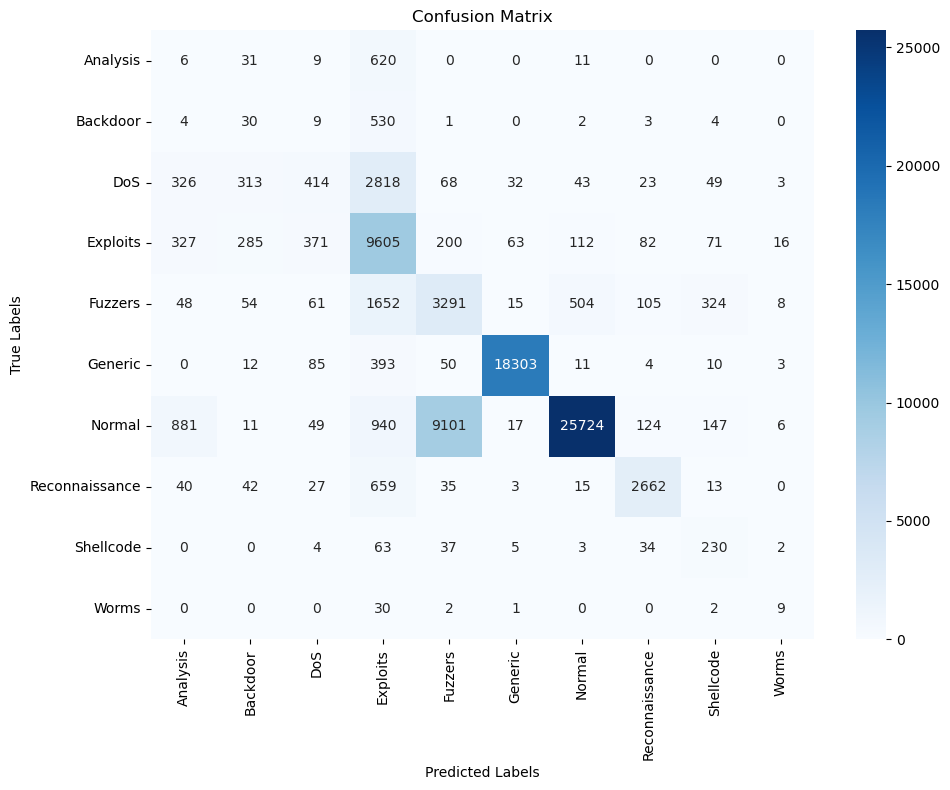

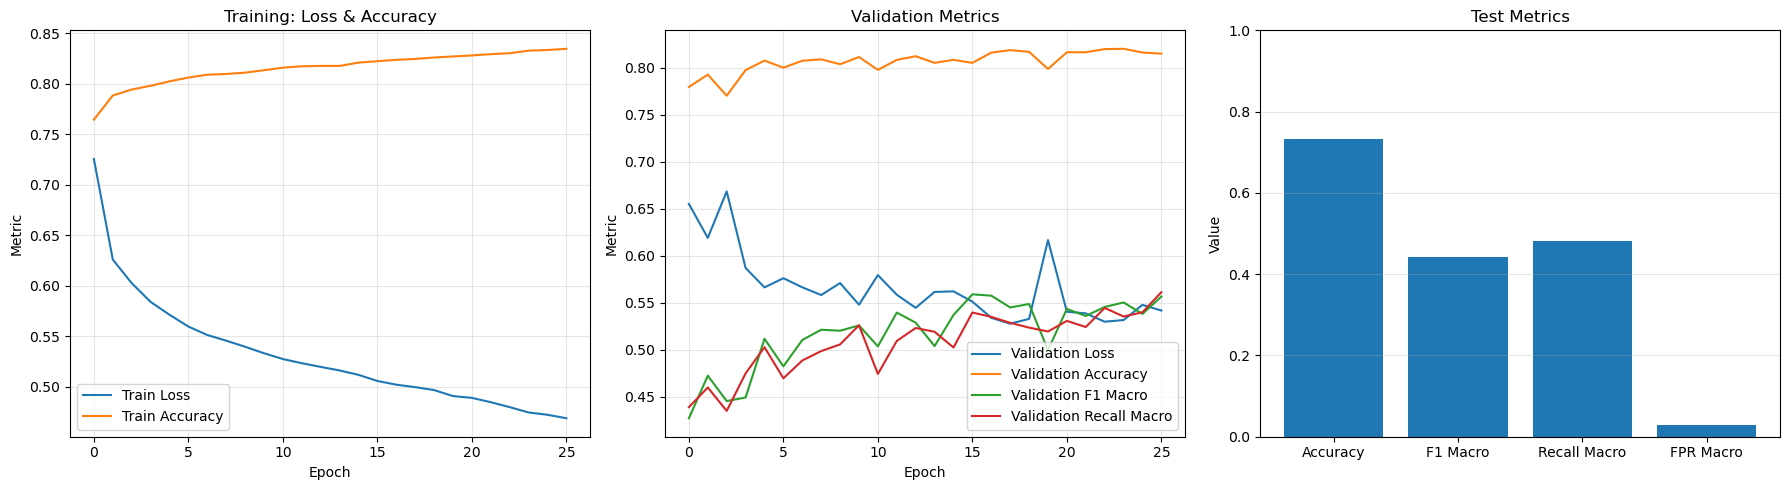

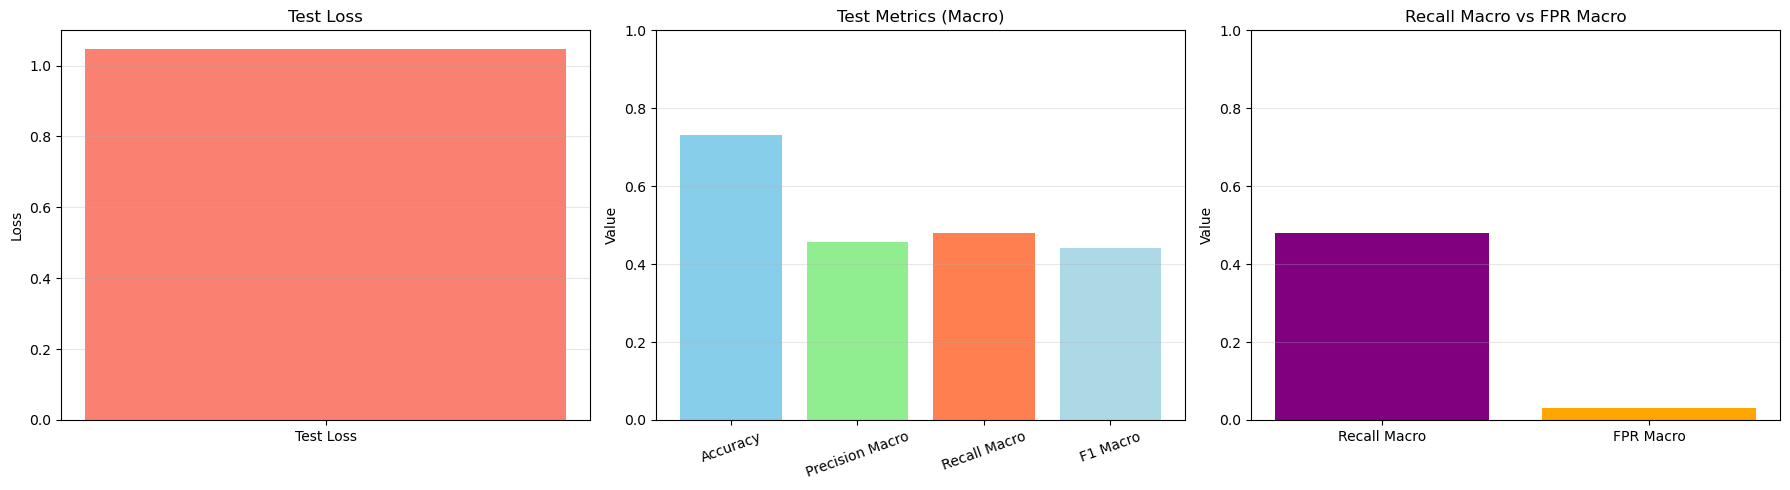

In [70]:
# =========================
# 14) Matriz de confusión y gráficas
# =========================
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["train_accuracy"], label="Train Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Metric")
axes[0].set_title("Training: Loss & Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["val_loss"], label="Validation Loss")
axes[1].plot(history["val_accuracy"], label="Validation Accuracy")
axes[1].plot(history["val_f1_macro"], label="Validation F1 Macro")
axes[1].plot(history["val_recall_macro"], label="Validation Recall Macro")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Metric")
axes[1].set_title("Validation Metrics")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

test_metrics_names = ["Accuracy", "F1 Macro", "Recall Macro", "FPR Macro"]
test_metrics_values = [test_accuracy, test_f1_macro, test_recall_macro, fpr_macro]

axes[2].bar(test_metrics_names, test_metrics_values)
axes[2].set_ylim(0, 1)
axes[2].set_ylabel("Value")
axes[2].set_title("Test Metrics")
axes[2].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].bar(['Test Loss'], [test_loss], color='salmon')
ax[0].set_title('Test Loss')
ax[0].set_ylabel('Loss')
ax[0].grid(True, axis='y', alpha=0.3)

metrics = ['Accuracy', 'Precision Macro', 'Recall Macro', 'F1 Macro']
values = [test_accuracy, test_precision_macro, test_recall_macro, test_f1_macro]

ax[1].bar(metrics, values, color=['skyblue', 'lightgreen', 'coral', 'lightblue'])
ax[1].set_ylim(0, 1)
ax[1].set_title('Test Metrics (Macro)')
ax[1].set_ylabel('Value')
ax[1].tick_params(axis='x', rotation=20)
ax[1].grid(True, axis='y', alpha=0.3)

ax[2].bar(['Recall Macro', 'FPR Macro'], [test_recall_macro, fpr_macro], color=['purple', 'orange'])
ax[2].set_ylim(0, 1)
ax[2].set_title('Recall Macro vs FPR Macro')
ax[2].set_ylabel('Value')
ax[2].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [73]:
# =========================
# 15) Guardar artefactos del notebook
# =========================
history_df = pd.DataFrame(history)
history_df.to_csv(ARTIFACT_DIR / "history_notebook.csv", index=False)

X_train_scaled.to_csv(ARTIFACT_DIR / "X_train_scaled.csv", index=False)
X_val_scaled.to_csv(ARTIFACT_DIR / "X_val_scaled.csv", index=False)
X_test_scaled.to_csv(ARTIFACT_DIR / "X_test_scaled.csv", index=False)

torch.save(X_train_tensor, ARTIFACT_DIR / "X_train.pt")
torch.save(y_train_tensor, ARTIFACT_DIR / "y_train.pt")
torch.save(X_val_tensor, ARTIFACT_DIR / "X_val.pt")
torch.save(y_val_tensor, ARTIFACT_DIR / "y_val.pt")
torch.save(X_test_tensor, ARTIFACT_DIR / "X_test.pt")
torch.save(y_test_tensor, ARTIFACT_DIR / "y_test.pt")

final_model_path = ARTIFACT_DIR / "best_model_state_dict.pt"
torch.save(model.state_dict(), final_model_path)

with open(ARTIFACT_DIR / "label_mapping_notebook.json", "w", encoding="utf-8") as f:
    json.dump(class_mapping, f, indent=2, ensure_ascii=False)

test_summary = {
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "test_precision_macro": float(test_precision_macro),
    "test_recall_macro": float(test_recall_macro),
    "test_f1_macro": float(test_f1_macro),
    "test_precision_weighted": float(test_precision_weighted),
    "test_recall_weighted": float(test_recall_weighted),
    "test_f1_weighted": float(test_f1_weighted),
    "test_fpr_macro": float(fpr_macro),
}

summary = {
    "dataset_name": DATASET_NAME,
    "n_train": int(X_train_tensor.shape[0]),
    "n_val": int(X_val_tensor.shape[0]),
    "n_test": int(X_test_tensor.shape[0]),
    "n_features": int(X_train_scaled.shape[1]),
    "batch_size": int(BATCH_SIZE),
    "num_epochs": int(NUM_EPOCHS),
    "learning_rate": float(LEARNING_RATE),

    "best_epoch_by_val_loss": int(best_epoch_by_val_loss) if best_epoch_by_val_loss is not None else None,
    "best_epoch_by_val_f1_macro": int(best_epoch_by_val_f1_macro) if best_epoch_by_val_f1_macro is not None else None,
    "best_val_loss": float(best_val_loss),
    "best_val_f1_macro": float(best_val_f1_macro),

    **test_summary,

    "model_state_dict_path": str(final_model_path.name),
}

with open(ARTIFACT_DIR / "summary_notebook.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

best_loss_src = ARTIFACT_DIR / "best_model_val_loss.pt"
best_f1_src = ARTIFACT_DIR / "best_model_val_f1_macro.pt"

if best_loss_src.exists():
    shutil.copy2(best_loss_src, ARTIFACT_DIR / "backup_best_model_val_loss.pt")

if best_f1_src.exists():
    shutil.copy2(best_f1_src, ARTIFACT_DIR / "backup_best_model_val_f1_macro.pt")

print("Artefactos guardados en:", ARTIFACT_DIR)
print(json.dumps(summary, indent=2, ensure_ascii=False))

Artefactos guardados en: c:\Users\rodol\OneDrive - SEIENER\03_Maestria\000_TESIS_ciberseguridad\worspace_visual\HALCCON_MULTICLASE\02_data\processed\unsw_nb15\catboost_label__clean_notebook
{
  "dataset_name": "unsw_nb15",
  "n_train": 149039,
  "n_val": 26302,
  "n_test": 82332,
  "n_features": 42,
  "batch_size": 256,
  "num_epochs": 30,
  "learning_rate": 0.0005,
  "best_epoch_by_val_loss": 18,
  "best_epoch_by_val_f1_macro": 16,
  "best_val_loss": 0.5277584848812021,
  "best_val_f1_macro": 0.5590154502541629,
  "test_loss": 1.0377821172546737,
  "test_accuracy": 0.721590633046689,
  "test_precision_macro": 0.47138260393117426,
  "test_recall_macro": 0.4776840314617722,
  "test_f1_macro": 0.4497791185253085,
  "test_precision_weighted": 0.8142906024162961,
  "test_recall_weighted": 0.721590633046689,
  "test_f1_weighted": 0.7474397363601798,
  "test_fpr_macro": 0.03056793180843736,
  "model_state_dict_path": "best_model_state_dict.pt"
}
